# Vision Offset Input Data EDA

Inspect the input data used by `ais_distance_prediction`, with emphasis on train/validation split shift, target distribution, and multi-view image statistics.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'ws_aic').exists():
    PROJECT_ROOT = Path('/home/whyz/aic_sejong')

DISTANCE_PROJECT = PROJECT_ROOT / 'ws_aic/src/ais/ais_distance_prediction'
sys.path.insert(0, str(DISTANCE_PROJECT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from model import (
    DEFAULT_DATASET_ROOT,
    expand_samples_by_available_ports,
    load_samples,
    port_id_from_sample,
    split_samples_by_stratified_group_kfold,
)

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

/media/hdd0/whyz/delivery-delay/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Use the same split settings as the training notebook so the summaries explain the observed validation gap.

In [2]:
DATASET_ROOT = DEFAULT_DATASET_ROOT
CAMERAS = ('left', 'center', 'right')
TARGET_KEYS = ('x_mm', 'y_mm', 'z_mm')
N_SPLITS = 5
FOLD_INDEX = 0
STRATIFY_KEYS = ('task_type', 'port_type')
SEED = 42
IMAGE_SAMPLE_PER_SPLIT = 160
IMAGE_STATS_SIZE = (288, 256)  # PIL size: width, height. Keeps 1152:1024 aspect ratio.

DATASET_ROOT

PosixPath('/home/whyz/aic_sejong/ws_aic/data/aic-entrance-dataset/v1.2/vision_offset_dataset')

## Load And Flatten Labels

The training dataset expands one frame into one row per available port. This notebook mirrors that behavior.

In [3]:
raw_samples = load_samples(DATASET_ROOT)
train_samples, val_samples, test_samples = split_samples_by_stratified_group_kfold(
    raw_samples,
    n_splits=N_SPLITS,
    fold_index=FOLD_INDEX,
    seed=SEED,
    stratify_keys=STRATIFY_KEYS,
)

split_samples = {
    'train': expand_samples_by_available_ports(train_samples),
    'val': expand_samples_by_available_ports(val_samples),
    'test': expand_samples_by_available_ports(test_samples),
}

def sample_to_row(sample, split):
    label = sample.get('_port_label') or sample['label']['plug_tip_to_port']
    row = {
        'split': split,
        'sample_id': sample.get('sample_id'),
        'episode_name': sample.get('episode_name'),
        'frame_index': sample.get('frame_index'),
        'task_type': sample.get('task_type'),
        'port_type': sample.get('port_type'),
        'port_name': sample.get('port_name', ''),
        'port_key': sample.get('_port_key', ''),
        'port_id': port_id_from_sample(sample),
    }
    for key in TARGET_KEYS:
        row[key] = float(label[key])
    for camera in CAMERAS:
        row[f'{camera}_image'] = sample['images'][camera]
    return row

rows = [sample_to_row(sample, split) for split, samples in split_samples.items() for sample in samples]
df = pd.DataFrame(rows)
df['offset_norm_mm'] = np.linalg.norm(df[list(TARGET_KEYS)].to_numpy(float), axis=1)

df.head()

,split,sample_id,episode_name,frame_index,task_type,port_type,port_name,port_key,port_id,x_mm,y_mm,z_mm,left_image,center_image,right_image,offset_norm_mm
0,train,20260508_102509_nic_rail0_sfp_port_0_task_1_co...,20260508_102509_nic_rail0_sfp_port_0_task_1,None,nic,sfp,sfp_port_0,nic_card_mount_0/sfp_port_0,0,0.486295,-0.741367,-146.714085,images/left/20260508_102509_nic_rail0_sfp_port...,images/center/20260508_102509_nic_rail0_sfp_po...,images/right/20260508_102509_nic_rail0_sfp_por...,146.716764
1,train,20260508_102509_nic_rail0_sfp_port_0_task_1_co...,20260508_102509_nic_rail0_sfp_port_0_task_1,None,nic,sfp,sfp_port_0,nic_card_mount_0/sfp_port_1,1,23.686307,-0.741395,-146.714204,images/left/20260508_102509_nic_rail0_sfp_port...,images/center/20260508_102509_nic_rail0_sfp_po...,images/right/20260508_102509_nic_rail0_sfp_por...,148.615775
2,train,20260508_102509_nic_rail0_sfp_port_0_task_1_co...,20260508_102509_nic_rail0_sfp_port_0_task_1,None,nic,sfp,sfp_port_0,nic_card_mount_0/sfp_port_0,0,2.364287,-0.879387,-136.570198,images/left/20260508_102509_nic_rail0_sfp_port...,images/center/20260508_102509_nic_rail0_sfp_po...,images/right/20260508_102509_nic_rail0_sfp_por...,136.593492
3,train,20260508_102509_nic_rail0_sfp_port_0_task_1_co...,20260508_102509_nic_rail0_sfp_port_0_task_1,None,nic,sfp,sfp_port_0,nic_card_mount_0/sfp_port_1,1,25.564299,-0.879415,-136.570317,images/left/20260508_102509_nic_rail0_sfp_port...,images/center/20260508_102509_nic_rail0_sfp_po...,images/right/20260508_102509_nic_rail0_sfp_por...,138.945162
4,train,20260508_102509_nic_rail0_sfp_port_0_task_1_co...,20260508_102509_nic_rail0_sfp_port_0_task_1,None,nic,sfp,sfp_port_0,nic_card_mount_0/sfp_port_0,0,5.351183,1.232676,-111.643332,images/left/20260508_102509_nic_rail0_sfp_port...,images/center/20260508_102509_nic_rail0_sfp_po...,images/right/20260508_102509_nic_rail0_sfp_por...,111.778300


## Split Balance

Check whether validation episodes differ in task, port, or target distribution.

In [4]:
split_summary = df.groupby('split').agg(
    rows=('sample_id', 'size'),
    episodes=('episode_name', 'nunique'),
    frames=('sample_id', 'nunique'),
    mean_norm_mm=('offset_norm_mm', 'mean'),
    p95_norm_mm=('offset_norm_mm', lambda s: s.quantile(0.95)),
)
split_summary

,rows,episodes,frames,mean_norm_mm,p95_norm_mm
split,,,,,
train,7840,28,4480,25.601764,36.373002
val,1760,7,1120,24.854292,35.494423


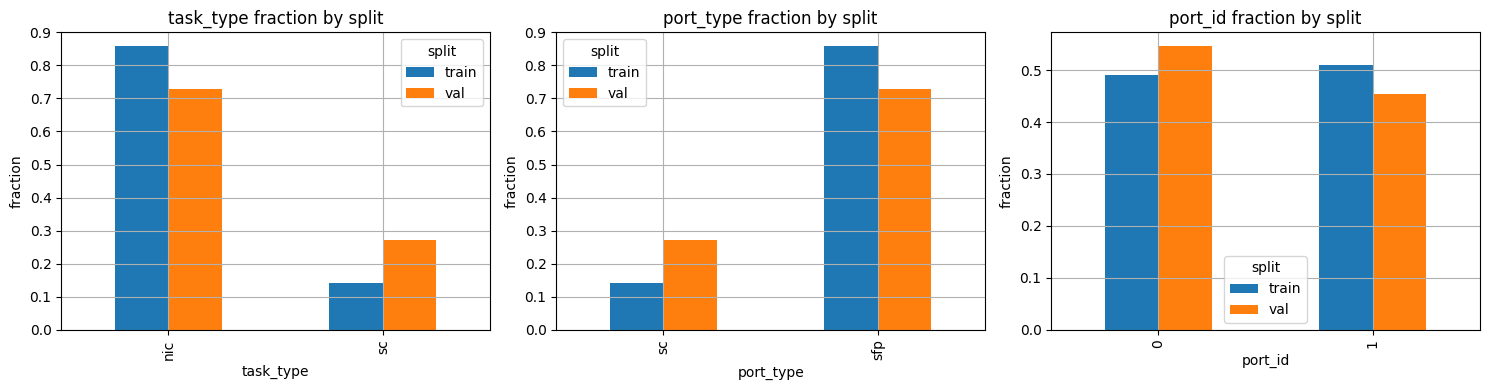

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, ['task_type', 'port_type', 'port_id']):
    counts = pd.crosstab(df[column], df['split'], normalize='columns')
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'{column} fraction by split')
    ax.set_ylabel('fraction')
plt.tight_layout()

## Target Distribution Shift

Large train/validation mismatch here can make validation error stay high even when train loss drops.

In [6]:
df.groupby('split')[list(TARGET_KEYS) + ['offset_norm_mm']].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

split                       train          val
x_mm           count  7840.000000  1760.000000
               mean      1.972455    -1.569421
               std      15.788391    14.504831
               min     -32.380394   -32.549243
               5%      -25.337702   -25.695965
               25%      -5.319841   -11.479218
               50%       1.420270     0.013248
               75%      13.010764     6.834815
               95%      27.702829    24.102356
               max      38.379930    36.835027
y_mm           count  7840.000000  1760.000000
               mean      1.243932    -0.167264
               std       5.459346     6.447064
               min     -14.321750   -21.862892
               5%       -7.215656   -10.145364
               25%      -2.461021    -4.135990
               50%       0.879059    -0.200300
               75%       4.597133     3.809158
               95%      12.489906    11.710918
               max      18.187069    16.085840
z_mm           count  7840.000000  1760.000000
               mean    -19.523959   -19.181858
               std      16.212458    15.372538
               min    -152.127206  -152.979638
               5%      -24.402570   -23.052423
               25%     -17.747679   -18.931738
               50%     -17.204986   -15.549406
               75%     -15.240949   -14.268408
               95%     -12.278381   -12.330416
               max      -6.185170    -6.427804
offset_norm_mm count  7840.000000  1760.000000
               mean     25.601764    24.854292
               std      16.524522    15.518634
               min      10.382194    11.206415
               5%       14.447717    14.290153
               25%      17.700311    17.175939
               50%      22.211620    22.257985
               75%      28.974182    28.006910
               95%      36.373002    35.494423
               max     152.795404   153.776628

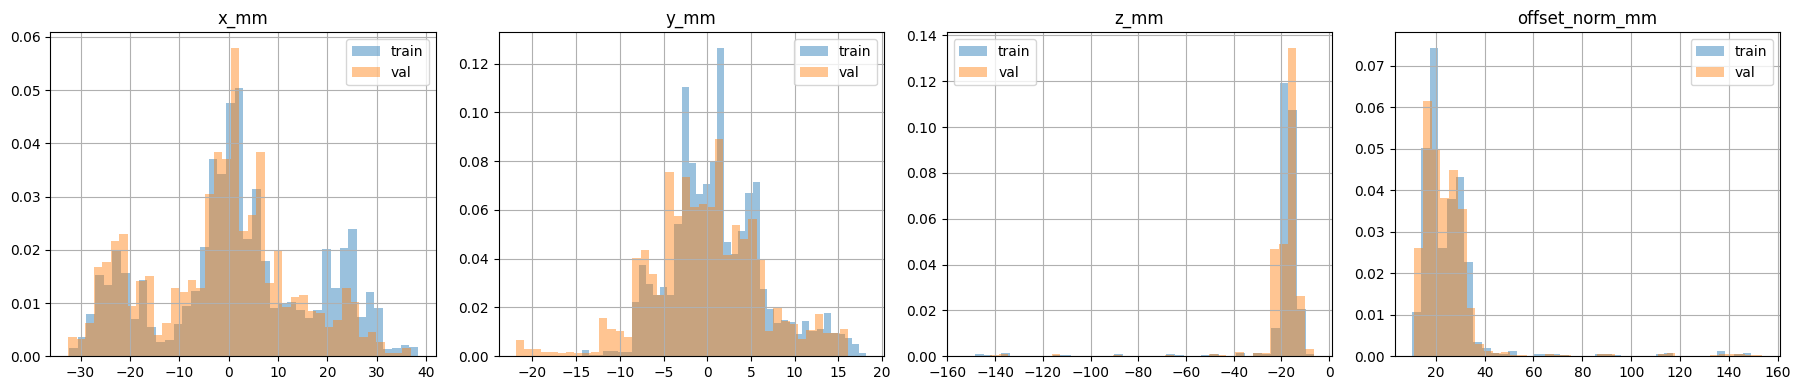

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, column in zip(axes, list(TARGET_KEYS) + ['offset_norm_mm']):
    for split, group in df.groupby('split'):
        if len(group):
            ax.hist(group[column], bins=40, alpha=0.45, density=True, label=split)
    ax.set_title(column)
    ax.legend()
plt.tight_layout()

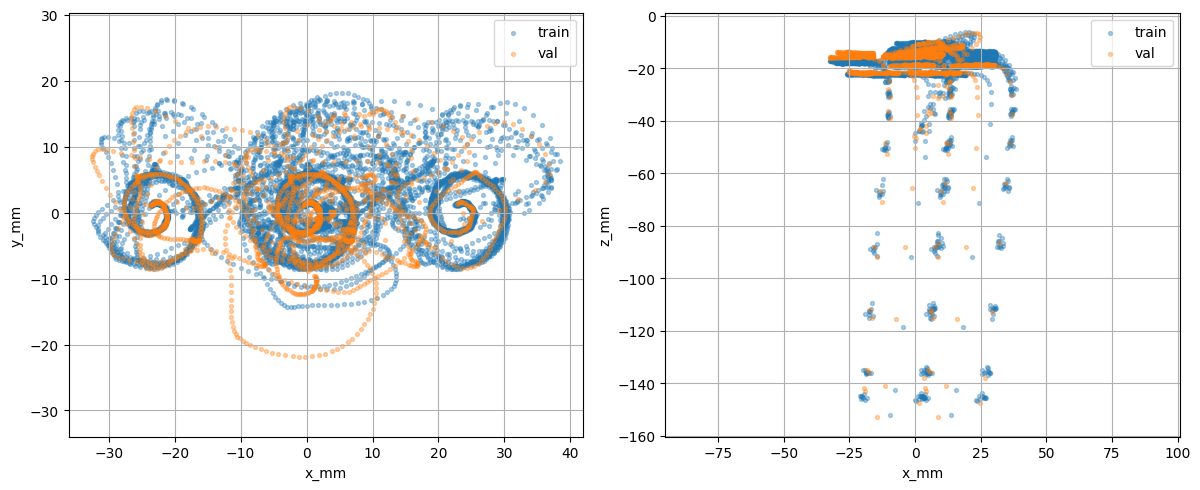

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for split, group in df.groupby('split'):
    axes[0].scatter(group['x_mm'], group['y_mm'], s=8, alpha=0.35, label=split)
    axes[1].scatter(group['x_mm'], group['z_mm'], s=8, alpha=0.35, label=split)
axes[0].set_xlabel('x_mm')
axes[0].set_ylabel('y_mm')
axes[1].set_xlabel('x_mm')
axes[1].set_ylabel('z_mm')
for ax in axes:
    ax.legend()
    ax.axis('equal')
plt.tight_layout()

## Episode-Level Shift

If validation episodes occupy different target regions, frame-level metrics can look like overfitting even with correct code.

In [9]:
episode_df = df.groupby(['split', 'episode_name']).agg(
    rows=('sample_id', 'size'),
    task_type=('task_type', lambda s: s.mode().iat[0] if len(s.mode()) else ''),
    port_type=('port_type', lambda s: s.mode().iat[0] if len(s.mode()) else ''),
    x_mean=('x_mm', 'mean'),
    y_mean=('y_mm', 'mean'),
    z_mean=('z_mm', 'mean'),
    norm_mean=('offset_norm_mm', 'mean'),
    norm_std=('offset_norm_mm', 'std'),
).reset_index()

episode_df.sort_values('norm_mean', ascending=False).head(20)

,split,episode_name,rows,task_type,port_type,x_mean,y_mean,z_mean,norm_mean,norm_std
24,train,20260508_105000_nic_rail2_sfp_port_1_task_1,320,nic,sfp,-0.891152,2.209810,-25.732156,29.828545,17.049894
34,val,20260508_105042_nic_rail3_sfp_port_1_task_1,320,nic,sfp,-3.674957,-1.285595,-24.930683,29.357733,16.738197
0,train,20260508_102509_nic_rail0_sfp_port_0_task_1,320,nic,sfp,12.991047,0.242934,-22.337997,28.862278,17.086087
33,val,20260508_104919_nic_rail1_sfp_port_0_task_1,320,nic,sfp,12.494537,1.119577,-22.064442,28.500741,17.341447
17,train,20260508_104332_nic_rail0_sfp_port_0_task_1,320,nic,sfp,12.676274,0.559900,-21.653234,28.204733,17.193029
23,train,20260508_104841_nic_rail0_sfp_port_0_task_1,320,nic,sfp,12.483251,1.511518,-20.923640,27.657347,17.504990
6,train,20260508_103319_nic_rail0_sfp_port_1_task_1,320,nic,sfp,-11.193543,1.229654,-21.237405,27.533753,16.756245
19,train,20260508_104529_nic_rail3_sfp_port_0_task_1,320,nic,sfp,12.384835,1.506423,-20.737944,27.505563,17.424890
13,train,20260508_103943_nic_rail2_sfp_port_1_task_1,320,nic,sfp,-10.678608,1.519230,-21.053656,27.282495,17.177128
11,train,20260508_103828_nic_rail0_sfp_port_1_task_1,320,nic,sfp,-11.587564,1.327855,-20.602112,27.208044,17.388327


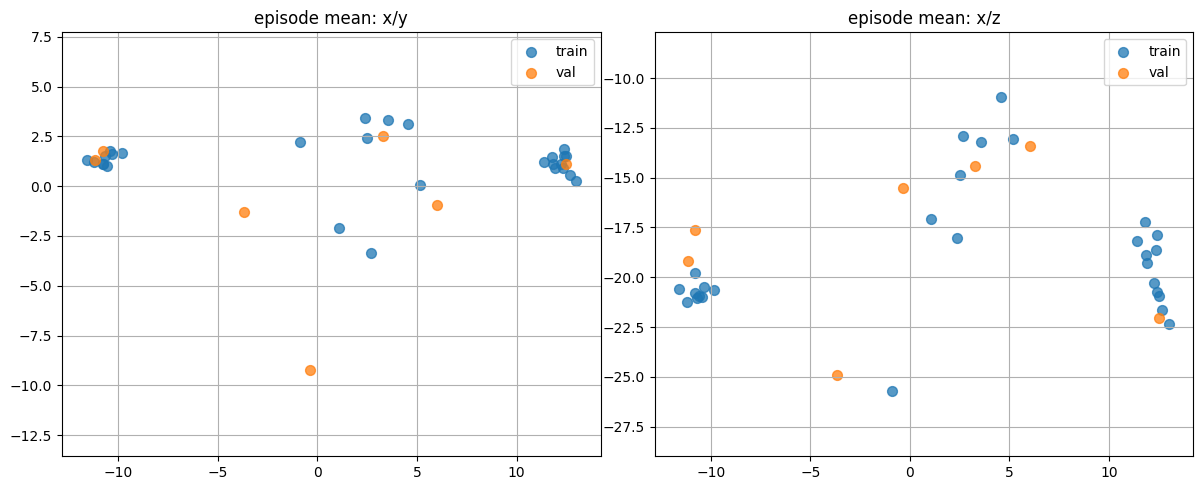

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for split, group in episode_df.groupby('split'):
    axes[0].scatter(group['x_mean'], group['y_mean'], s=50, alpha=0.75, label=split)
    axes[1].scatter(group['x_mean'], group['z_mean'], s=50, alpha=0.75, label=split)
axes[0].set_title('episode mean: x/y')
axes[1].set_title('episode mean: x/z')
for ax in axes:
    ax.legend()
    ax.axis('equal')
plt.tight_layout()

## Image And View Statistics

This samples images to look for split/view-specific brightness, contrast, or cross-view differences.

In [11]:
rng = np.random.default_rng(SEED)
sampled_parts = []
for split, group in df.groupby('split'):
    n = min(IMAGE_SAMPLE_PER_SPLIT, len(group))
    sampled_parts.append(group.sample(n=n, random_state=SEED) if n else group)
image_sample_df = pd.concat(sampled_parts, ignore_index=True)

def load_rgb(path):
    with Image.open(DATASET_ROOT / path) as image:
        image = image.convert('RGB')
        image = image.resize(IMAGE_STATS_SIZE)
        return np.asarray(image, dtype=np.float32) / 255.0

image_rows = []
for _, row in image_sample_df.iterrows():
    images = {camera: load_rgb(row[f'{camera}_image']) for camera in CAMERAS}
    for camera, image in images.items():
        gray = image.mean(axis=2)
        image_rows.append({
            'split': row['split'],
            'episode_name': row['episode_name'],
            'sample_id': row['sample_id'],
            'camera': camera,
            'brightness': float(gray.mean()),
            'contrast': float(gray.std()),
            'red_mean': float(image[..., 0].mean()),
            'green_mean': float(image[..., 1].mean()),
            'blue_mean': float(image[..., 2].mean()),
        })
    image_rows.append({
        'split': row['split'],
        'episode_name': row['episode_name'],
        'sample_id': row['sample_id'],
        'camera': 'left-center absdiff',
        'brightness': float(np.abs(images['left'] - images['center']).mean()),
        'contrast': np.nan,
        'red_mean': np.nan,
        'green_mean': np.nan,
        'blue_mean': np.nan,
    })
    image_rows.append({
        'split': row['split'],
        'episode_name': row['episode_name'],
        'sample_id': row['sample_id'],
        'camera': 'right-center absdiff',
        'brightness': float(np.abs(images['right'] - images['center']).mean()),
        'contrast': np.nan,
        'red_mean': np.nan,
        'green_mean': np.nan,
        'blue_mean': np.nan,
    })

image_stats_df = pd.DataFrame(image_rows)
image_stats_df.head()

,split,episode_name,sample_id,camera,brightness,contrast,red_mean,green_mean,blue_mean
0,train,20260508_103357_nic_rail1_sfp_port_0_task_1,20260508_103357_nic_rail1_sfp_port_0_task_1_co...,left,0.586980,0.316889,0.587630,0.587461,0.585848
1,train,20260508_103357_nic_rail1_sfp_port_0_task_1,20260508_103357_nic_rail1_sfp_port_0_task_1_co...,center,0.577155,0.315959,0.579330,0.578355,0.573781
2,train,20260508_103357_nic_rail1_sfp_port_0_task_1,20260508_103357_nic_rail1_sfp_port_0_task_1_co...,right,0.584411,0.313735,0.588543,0.584968,0.579721
3,train,20260508_103357_nic_rail1_sfp_port_0_task_1,20260508_103357_nic_rail1_sfp_port_0_task_1_co...,left-center absdiff,0.237570,NaN,NaN,NaN,NaN
4,train,20260508_103357_nic_rail1_sfp_port_0_task_1,20260508_103357_nic_rail1_sfp_port_0_task_1_co...,right-center absdiff,0.292221,NaN,NaN,NaN,NaN


In [12]:
image_stats_df.groupby(['split', 'camera'])[['brightness', 'contrast', 'red_mean', 'green_mean', 'blue_mean']].mean().round(4)

brightness  contrast  red_mean  green_mean  \
split camera                                                             
train center                    0.5646    0.3093    0.5670      0.5634   
      left                      0.5866    0.3149    0.5877      0.5853   
      left-center absdiff       0.2336       NaN       NaN         NaN   
      right                     0.5580    0.2983    0.5619      0.5566   
      right-center absdiff      0.2646       NaN       NaN         NaN   
val   center                    0.5222    0.2874    0.5256      0.5182   
      left                      0.5432    0.3048    0.5458      0.5388   
      left-center absdiff       0.2373       NaN       NaN         NaN   
      right                     0.5216    0.2668    0.5257      0.5190   
      right-center absdiff      0.2442       NaN       NaN         NaN   

                            blue_mean  
split camera                           
train center                   0.5634  
      left                     0.5867  
      left-center absdiff         NaN  
      right                    0.5554  
      right-center absdiff        NaN  
val   center                   0.5230  
      left                     0.5449  
      left-center absdiff         NaN  
      right                    0.5200  
      right-center absdiff        NaN

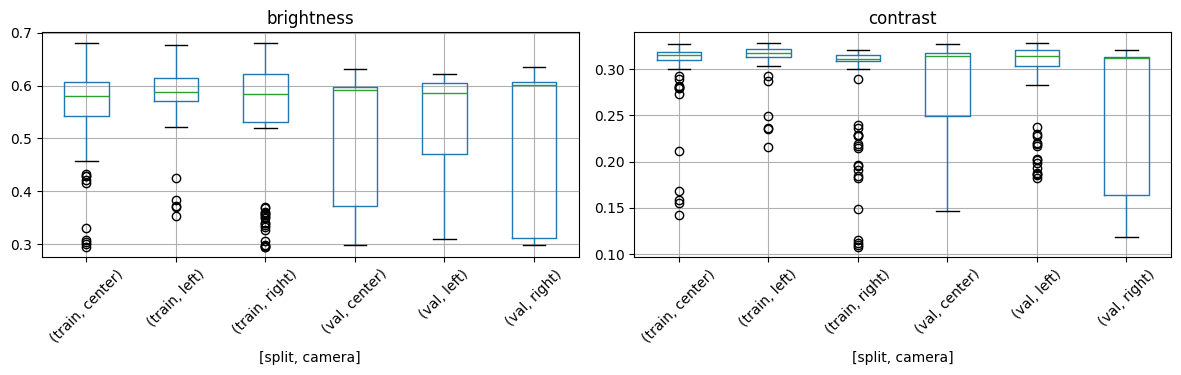

In [13]:
real_views = image_stats_df[image_stats_df['camera'].isin(CAMERAS)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
real_views.boxplot(column='brightness', by=['split', 'camera'], ax=axes[0], rot=45)
real_views.boxplot(column='contrast', by=['split', 'camera'], ax=axes[1], rot=45)
axes[0].set_title('brightness')
axes[1].set_title('contrast')
plt.suptitle('')
plt.tight_layout()

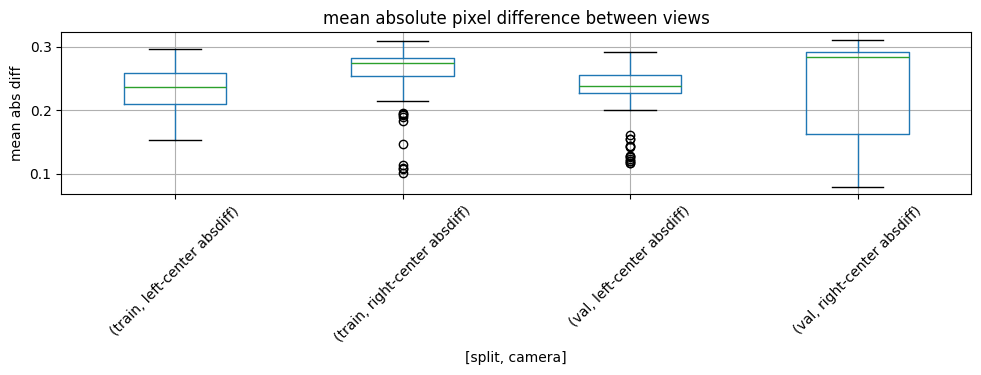

In [14]:
diff_views = image_stats_df[image_stats_df['camera'].str.contains('absdiff', regex=False)]
ax = diff_views.boxplot(column='brightness', by=['split', 'camera'], rot=45, figsize=(10, 4))
ax.set_title('mean absolute pixel difference between views')
ax.set_ylabel('mean abs diff')
plt.suptitle('')
plt.tight_layout()

## Multiview Montage

Visual sanity check for sampled train and validation rows.

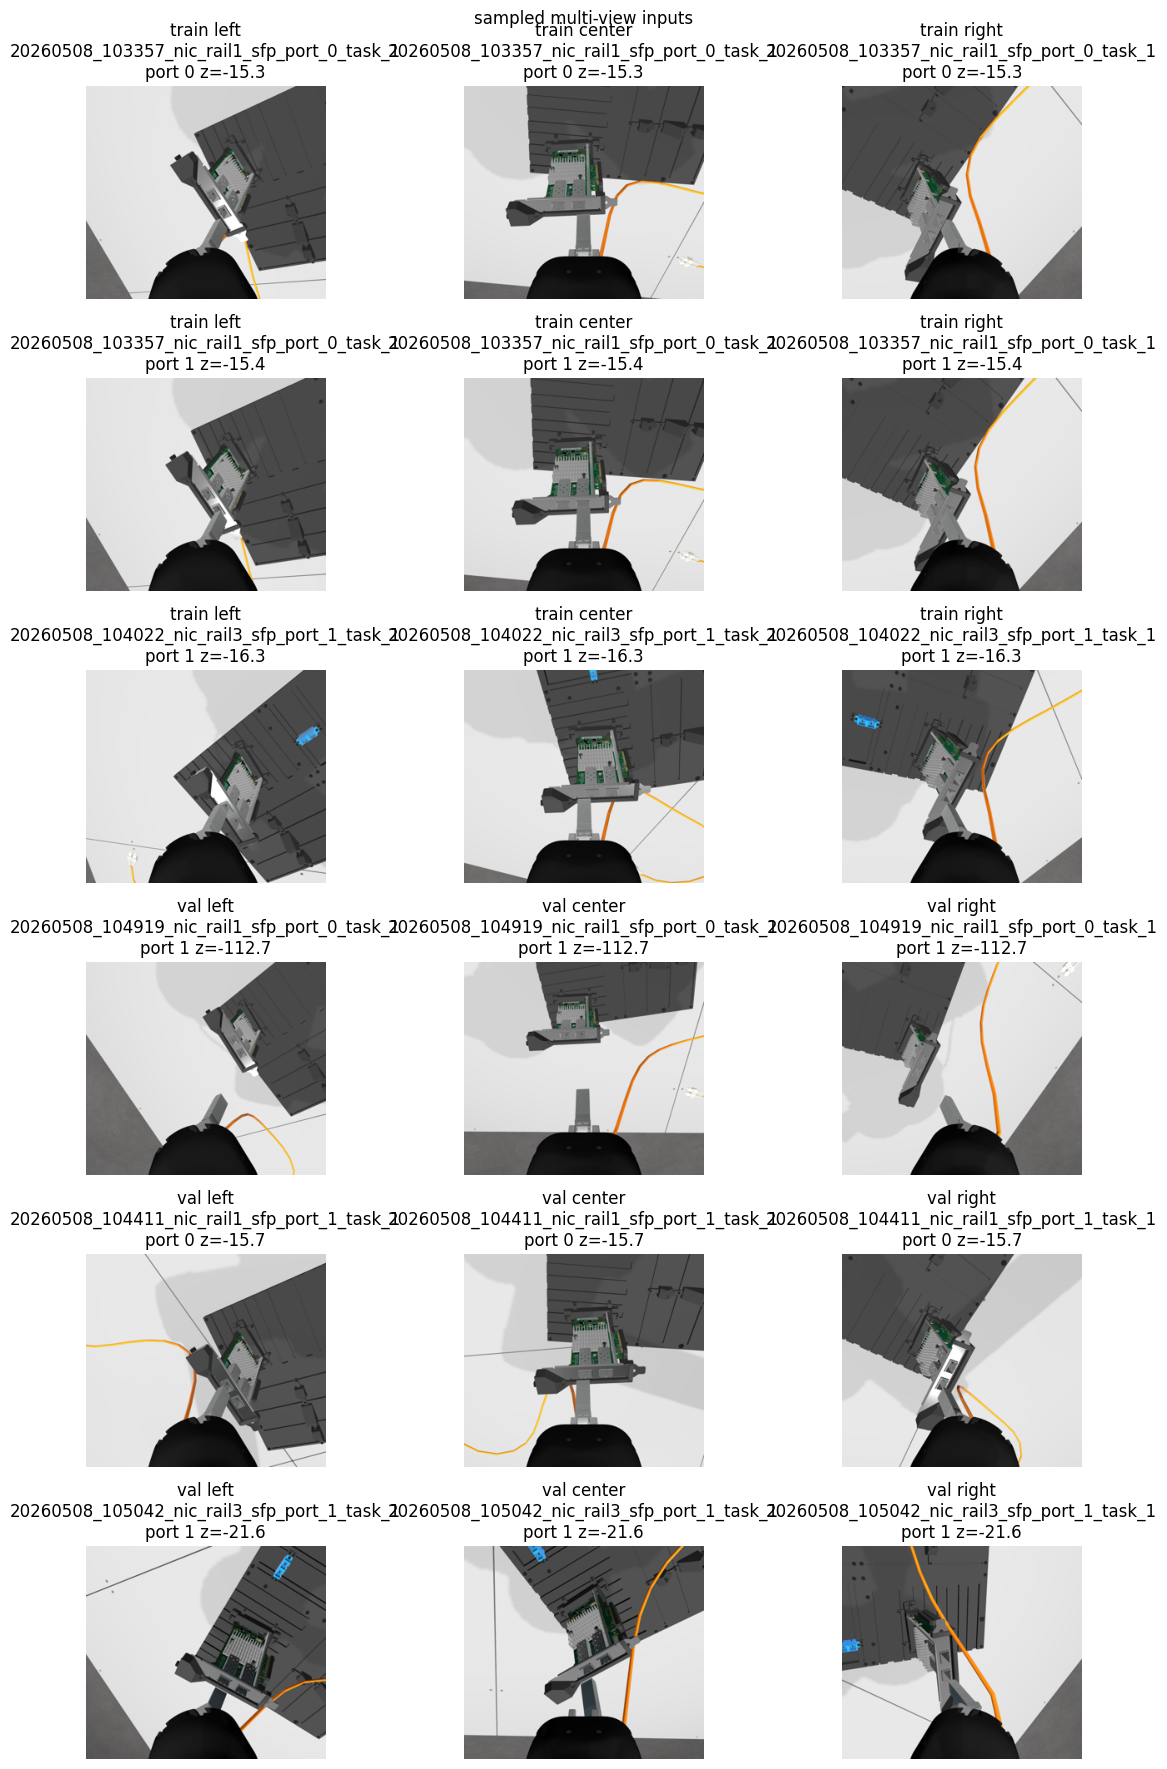

In [15]:
def show_triplets(rows, title):
    n = len(rows)
    fig, axes = plt.subplots(n, len(CAMERAS), figsize=(4 * len(CAMERAS), 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    for r, (_, row) in enumerate(rows.iterrows()):
        for c, camera in enumerate(CAMERAS):
            with Image.open(DATASET_ROOT / row[f'{camera}_image']) as image:
                image = image.convert('RGB').resize(IMAGE_STATS_SIZE)
            axes[r, c].imshow(image)
            axes[r, c].axis('off')
            axes[r, c].set_title(f"{row['split']} {camera}\n{row['episode_name']}\nport {row['port_id']} z={row['z_mm']:.1f}")
    fig.suptitle(title)
    plt.tight_layout()

preview_rows = pd.concat([
    df[df['split'] == 'train'].sample(n=min(3, (df['split'] == 'train').sum()), random_state=SEED),
    df[df['split'] == 'val'].sample(n=min(3, (df['split'] == 'val').sum()), random_state=SEED),
])
show_triplets(preview_rows, 'sampled multi-view inputs')

## Quick Checks

Use these tables to decide whether the validation gap is likely caused by split distribution, data imbalance, or image-domain shift.

In [16]:
checks = {
    'split_rows': df['split'].value_counts().to_dict(),
    'split_episodes': df.groupby('split')['episode_name'].nunique().to_dict(),
    'task_fraction': pd.crosstab(df['task_type'], df['split'], normalize='columns').round(3),
    'port_fraction': pd.crosstab(df['port_id'], df['split'], normalize='columns').round(3),
    'target_mean_by_split': df.groupby('split')[list(TARGET_KEYS)].mean().round(3),
    'target_std_by_split': df.groupby('split')[list(TARGET_KEYS)].std().round(3),
}

checks

{'split_rows': {'train': 7840, 'val': 1760},
 'split_episodes': {'train': 28, 'val': 7},
 'task_fraction': split      train    val
 task_type              
 nic        0.857  0.727
 sc         0.143  0.273,
 'port_fraction': split    train    val
 port_id              
 0         0.49  0.545
 1         0.51  0.455,
 'target_mean_by_split':         x_mm   y_mm    z_mm
 split                      
 train  1.972  1.244 -19.524
 val   -1.569 -0.167 -19.182,
 'target_std_by_split':          x_mm   y_mm    z_mm
 split                       
 train  15.788  5.459  16.212
 val    14.505  6.447  15.373}